# Depression Type Classification Analysis

This notebook reproduces the core analysis for the uploaded dataset **Mental Health Classification.csv**.

## What this notebook does
- loads and audits the dataset
- performs exploratory data analysis
- runs Chi-Square tests for selected categorical variables
- compares key numerical variables across classes
- trains **Logistic Regression** and **Gaussian Naive Bayes**
- evaluates both models using **Accuracy** and **Macro F1-score**
- visualizes feature importance and the confusion matrix

The target variable used in this notebook is **`Depression_Type`**.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Model-ready data now comes from the dbt pipeline (dbt/) instead of the raw CSV
# directly - see dbt/models/marts/fct_mental_health_model_input.sql. Run
# `dbt seed && dbt run` in dbt/ first to (re)build this table.
DUCKDB_PATH = r"dbt/depression.duckdb"

if not __import__("os").path.exists(DUCKDB_PATH):
    raise FileNotFoundError(
        f"{DUCKDB_PATH!r} not found. Run this from the repo root after building "
        "the dbt pipeline: cd dbt && dbt seed && dbt run"
    )

con = duckdb.connect(DUCKDB_PATH, read_only=True)
df = con.execute("select * from main_marts.fct_mental_health_model_input").df()
con.close()

# Restore the original column names the rest of this notebook already expects -
# staging renamed them to snake_case, but the analysis below is unchanged.
df = df.drop(columns=["response_id"]).rename(columns={
    "gender": "Gender",
    "age": "Age",
    "education_level": "Education_Level",
    "employment_status": "Employment_Status",
    "depression_type": "Depression_Type",
    "symptoms": "Symptoms",
    "low_energy": "Low_Energy",
    "low_self_esteem": "Low_SelfEsteem",
    "search_depression_online": "Search_Depression_Online",
    "worsening_depression": "Worsening_Depression",
    "overeating_level": "Your overeating level",
    "eating_frequency": "How many times you eat ",
    "social_media_hours": "SocialMedia_Hours",
    "social_media_while_eating": "SocialMedia_WhileEating",
    "sleep_hours": "Sleep_Hours",
    "nervous_level": "Nervous_Level",
    "depression_score": "Depression_Score",
    "coping_methods": "Coping_Methods",
    "self_harm": "Self_Harm",
    "mental_health_support": "Mental_Health_Support",
    "suicide_attempts": "Suicide_Attempts",
})

target = "Depression_Type"
df.head()

,Gender,Age,Education_Level,Employment_Status,Symptoms,Low_Energy,Low_SelfEsteem,Search_Depression_Online,Worsening_Depression,Your overeating level,...,SocialMedia_Hours,SocialMedia_WhileEating,Sleep_Hours,Nervous_Level,Depression_Score,Coping_Methods,Self_Harm,Mental_Health_Support,Suicide_Attempts,Depression_Type
0,1,25,2,3,11,1,1,1,1,4,...,10,3,10,10,10,11,0,0,0,5
1,1,25,2,2,0,1,1,0,1,4,...,8,3,4,10,10,0,0,1,0,5
2,1,25,2,3,5,1,1,1,1,4,...,10,3,4,10,10,0,1,1,1,2
3,0,25,2,2,7,0,1,0,1,2,...,4,3,3,10,10,5,1,1,1,6
4,1,25,2,2,5,0,0,0,0,8,...,3,3,7,1,3,0,0,0,0,6


## 1. Dataset audit

In [2]:
print("Shape:", df.shape)
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
print("\nColumns:")
for c in df.columns:
    print("-", c)

print("\nTarget distribution:")
print(df[target].value_counts().sort_index())


Shape: (1998, 21)
Missing values: 0
Duplicate rows: 0

Columns:
- Gender
- Age
- Education_Level
- Employment_Status
- Symptoms
- Low_Energy
- Low_SelfEsteem
- Search_Depression_Online
- Worsening_Depression
- Your overeating level
- How many times you eat 
- SocialMedia_Hours
- SocialMedia_WhileEating
- Sleep_Hours
- Nervous_Level
- Depression_Score
- Coping_Methods
- Self_Harm
- Mental_Health_Support
- Suicide_Attempts
- Depression_Type

Target distribution:
Depression_Type
0      32
1      33
2     449
3      31
4     131
5     386
6     193
7      32
8      21
9     627
10     29
11     34
Name: count, dtype: int64


## 2. Class distribution

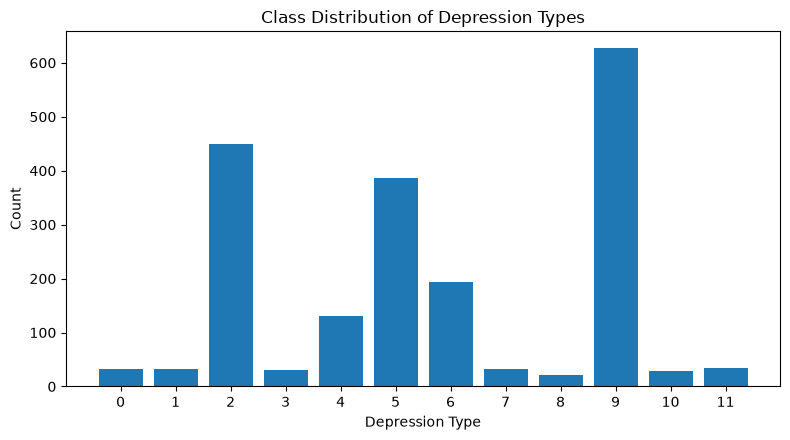

In [3]:
counts = df[target].value_counts().sort_index()

plt.figure(figsize=(8, 4.5))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Class Distribution of Depression Types")
plt.xlabel("Depression Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 3. Correlation matrix for numeric predictors

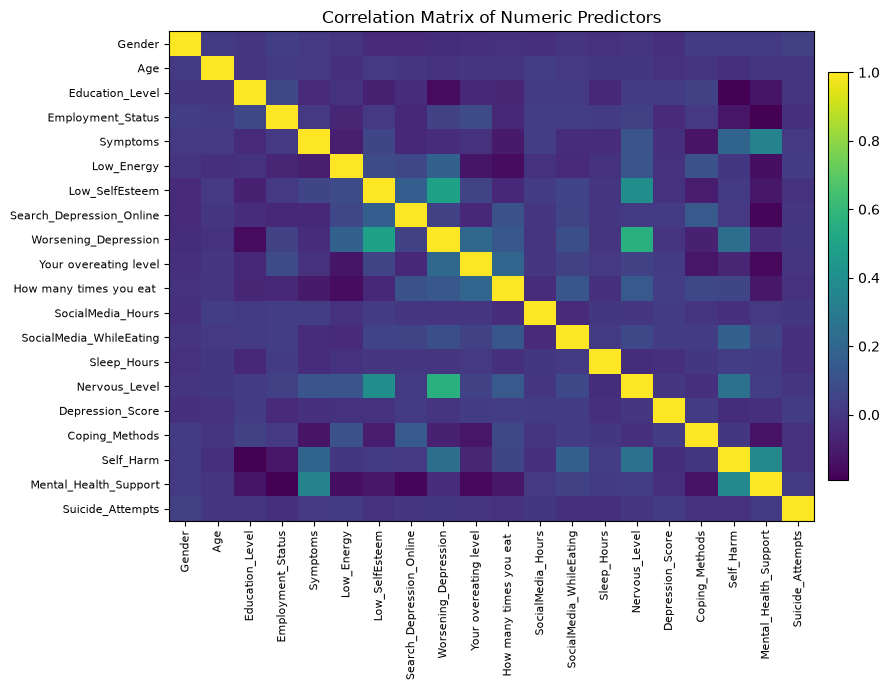

In [4]:
numeric_df = df.select_dtypes(include="number").copy()
feature_numeric = numeric_df.drop(columns=[target], errors="ignore")

corr = feature_numeric.corr()

plt.figure(figsize=(9, 7))
im = plt.imshow(corr, aspect="auto")
plt.title("Correlation Matrix of Numeric Predictors")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=8)
plt.yticks(range(len(corr.columns)), corr.columns, fontsize=8)
plt.set_cmap('viridis')
plt.colorbar(im, fraction=0.03, pad=0.02)
plt.tight_layout()
plt.show()


## 4. Categorical variable analysis with Chi-Square tests

In [5]:
encoding_info = {
    "Gender": {
        "xlabel": "Gender (0 = Male, 1 = Female)",
        "tick_map": {0: "Male", 1: "Female"}
    },
    "Education_Level": {
        "xlabel": "Education Level (0=Primary, 1=High School, 2=Undergrad, 3=Postgrad)",
        "tick_map": {0: "Primary", 1: "High School", 2: "Undergrad", 3: "Postgrad"}
    },
    "Employment_Status": {
        "xlabel": "Employment Status (0=Unemp, 1=Student, 2=Employed, 3=Self-employed, 4=Other)",
        "tick_map": {0: "Unemp", 1: "Student", 2: "Employed", 3: "Self-emp", 4: "Other"}
    },
    "Symptoms": {
        "xlabel": "Symptoms (encoded symptom clusters)"
    },
    "Low_Energy": {
        "ylabel": "Low Energy (0=No, 1=Yes, 2=Occasionally)"
    },
    "Low_SelfEsteem": {
        "xlabel": "Low Self-Esteem (0=No, 1=Yes, 2=Occasionally)",
        "ylabel": "Low Self-Esteem (0=No, 1=Yes, 2=Occasionally)",
        "tick_map": {0: "No", 1: "Yes", 2: "Occasionally"}
    },
    "Search_Depression_Online": {
        "xlabel": "Search Depression Online (0=No, 1=Yes)",
        "tick_map": {0: "No", 1: "Yes"}
    },
    "Worsening_Depression": {
        "xlabel": "Worsening Depression (0=No, 1=Yes)",
        "ylabel": "Worsening Depression (0=No, 1=Yes)",
        "tick_map": {0: "No", 1: "Yes"}
    },
    "Your overeating level": {
        "ylabel": "Overeating Level (0=None, 1–4=Mild, 5–8=Moderate, 9–12=Severe)"
    },
    "Overeating_Level": {
        "xlabel": "Overeating Level (0=None, 1–4=Mild, 5–8=Moderate, 9–12=Severe)"
    },
    "How many times you eat ": {
        "ylabel": "Eating Frequency (0≤2, 1=3 meals, 2=4–5, 3>5)"
    },
    "Eating_Frequency": {
        "xlabel": "Eating Frequency (0≤2, 1=3 meals, 2=4–5, 3>5)",
        "tick_map": {0: "≤2", 1: "3", 2: "4–5", 3: ">5"}
    },
    "SocialMedia_WhileEating": {
        "xlabel": "Social Media While Eating (0=Never, 1=Rarely, 2=Often, 3=Always)",
        "tick_map": {0: "Never", 1: "Rarely", 2: "Often", 3: "Always"}
    },
    "Self_Harm": {
        "xlabel": "Self Harm (0=No, 1=Yes)",
        "ylabel": "Self Harm (0=No, 1=Yes)",
        "tick_map": {0: "No", 1: "Yes"}
    },
    "Mental_Health_Support": {
        "xlabel": "Mental Health Support (0=No, 1=Yes)",
        "tick_map": {0: "No", 1: "Yes"}
    },
    "Suicide_Attempts": {
        "xlabel": "Suicide Attempts (0=None, 1=Once, 2=Twice, 3=3+)",
        "ylabel": "Suicide Attempts (0=None, 1=Once, 2=Twice, 3=3+)",
        "tick_map": {0: "None", 1: "Once", 2: "Twice", 3: "3+"}
    }
}

def get_axis_label(col_name, axis="xlabel"):
    return encoding_info.get(col_name, {}).get(axis, col_name)

def relabel_axis_ticks(ax, col_name, axis="x"):
    tick_map = encoding_info.get(col_name, {}).get("tick_map")
    if not tick_map:
        return
    if axis == "x":
        current = ax.get_xticks()
        labels = [tick_map.get(int(t), str(int(t))) if float(t).is_integer() else str(t) for t in current]
        ax.set_xticklabels(labels, rotation=0)
    elif axis == "y":
        current = ax.get_yticks()
        labels = [tick_map.get(int(t), str(int(t))) if float(t).is_integer() else str(t) for t in current]
        ax.set_yticklabels(labels)

candidate_categorical = [
    "Gender", "Education_Level", "Employment_Status", "Search_Depression_Online",
    "Mental_Health_Support", "SocialMedia_WhileEating", "Symptoms", "Worsening_Depression",
    "How many times you eat", "Coping_Methods", "Self_Harm", "Suicide_Attempts"
]
categorical_cols = [c for c in candidate_categorical if c in df.columns]

chi_results = []

for col in categorical_cols:
    ct = pd.crosstab(df[col], df[target])
    chi2, p, dof, expected = stats.chi2_contingency(ct)
    n = ct.to_numpy().sum()
    r, k = ct.shape
    cramers_v = np.sqrt((chi2 / n) / min(r - 1, k - 1)) if min(r - 1, k - 1) > 0 else np.nan
    chi_results.append({
        "Variable": col,
        "Chi-square": chi2,
        "p-value": p,
        "df": dof
    })

chi_df = pd.DataFrame(chi_results).sort_values("p-value")
chi_df

,Variable,Chi-square,p-value,df
2,Employment_Status,1902.062140,0.000000e+00,44
6,Symptoms,10409.468593,0.000000e+00,154
8,Coping_Methods,6327.147936,0.000000e+00,143
1,Education_Level,1141.592817,1.344299e-218,33
5,SocialMedia_WhileEating,754.930623,2.058183e-137,33
4,Mental_Health_Support,420.995879,2.123266e-83,11
3,Search_Depression_Online,352.401389,7.522430e-69,11
7,Worsening_Depression,298.914316,1.483320e-57,11
9,Self_Harm,233.766211,6.938044e-44,11
10,Suicide_Attempts,46.032459,6.537843e-02,33


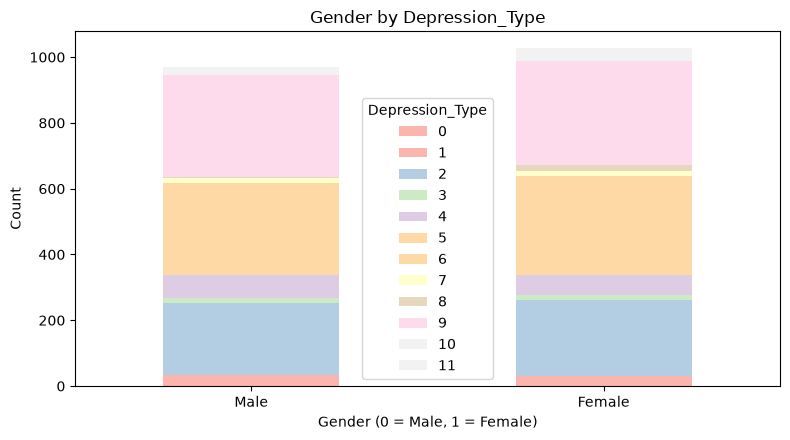

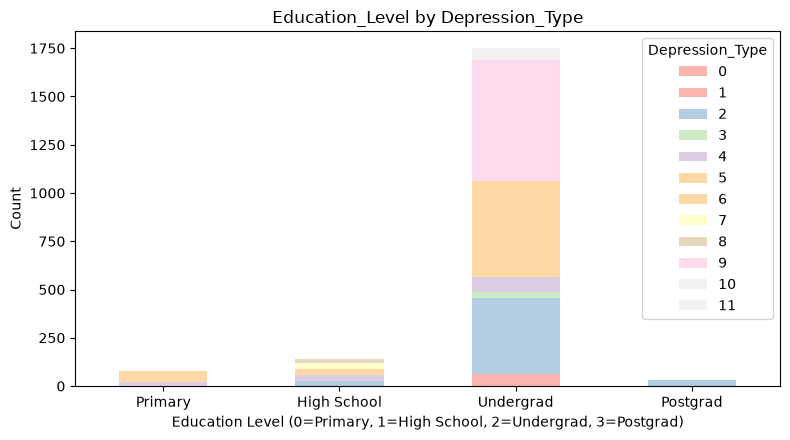

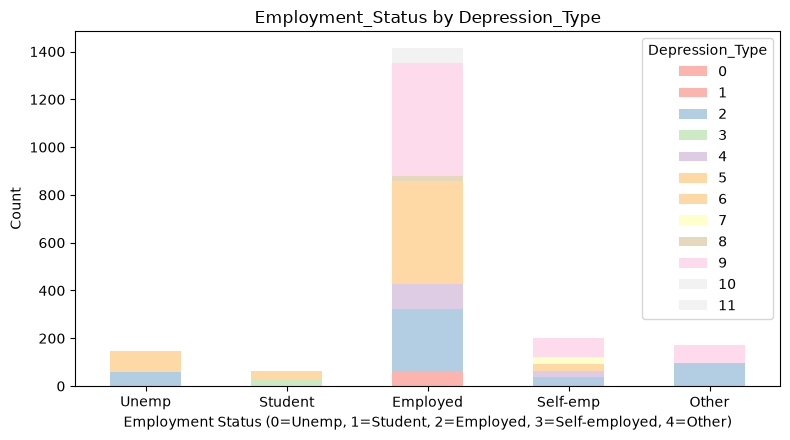

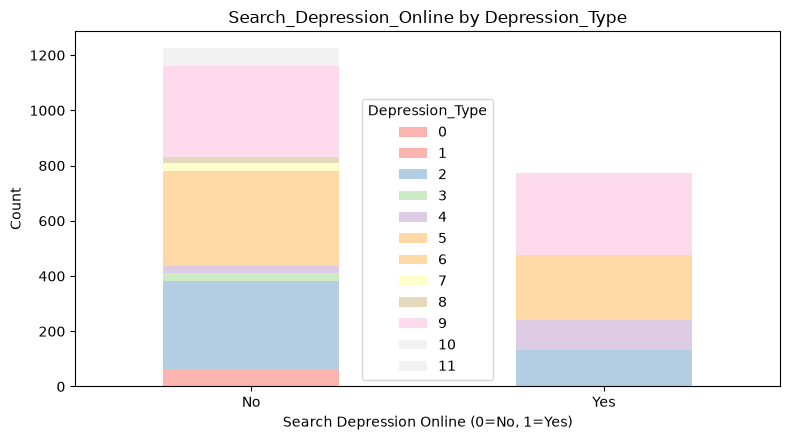

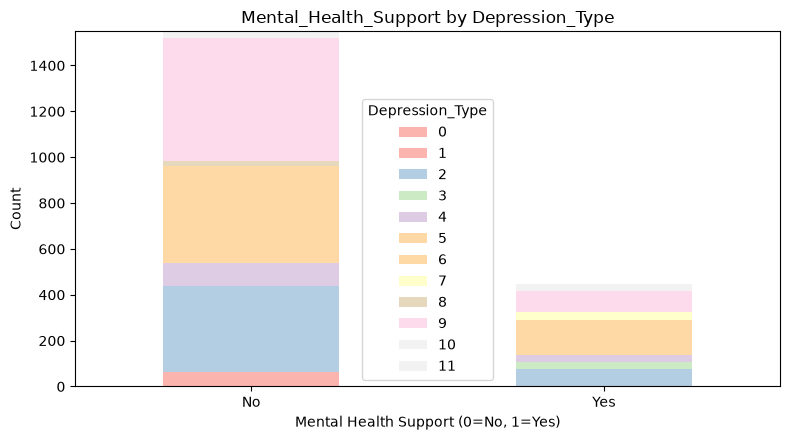

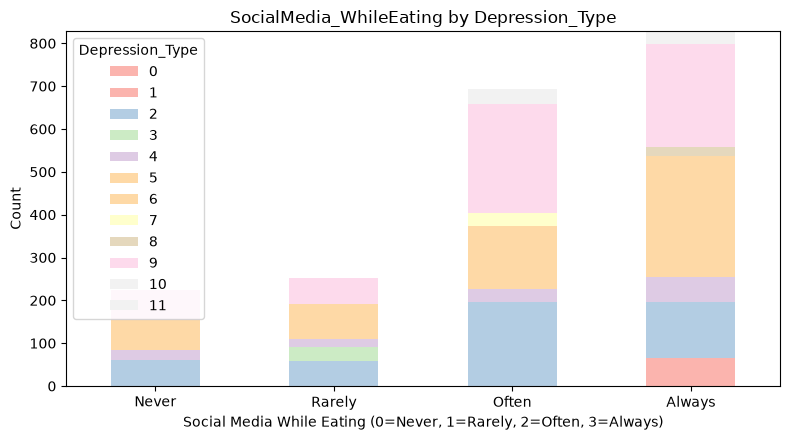

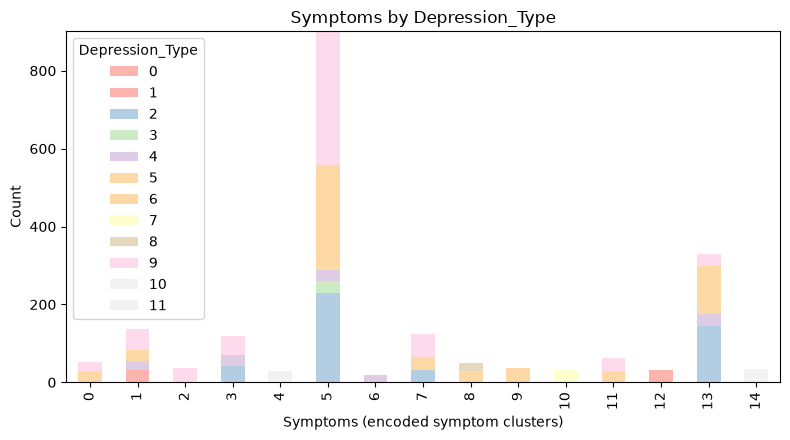

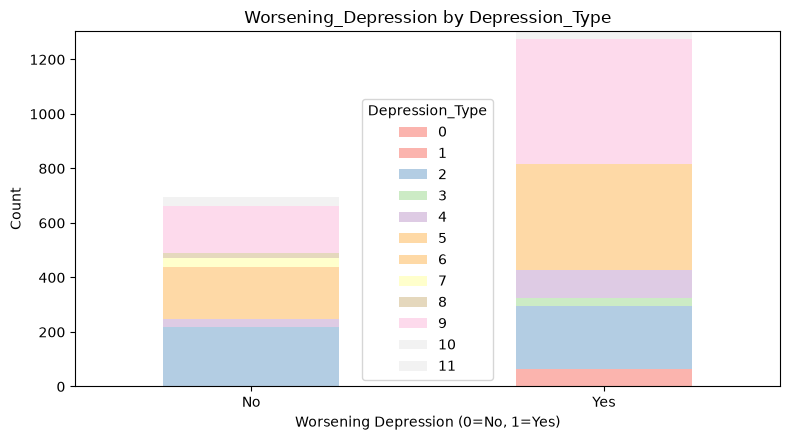

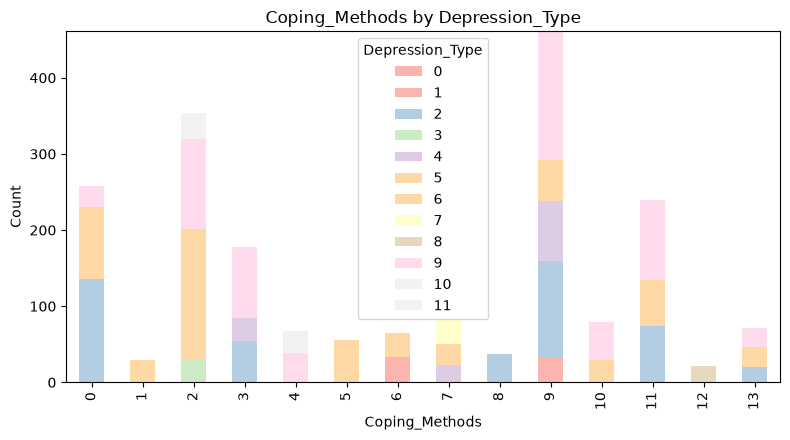

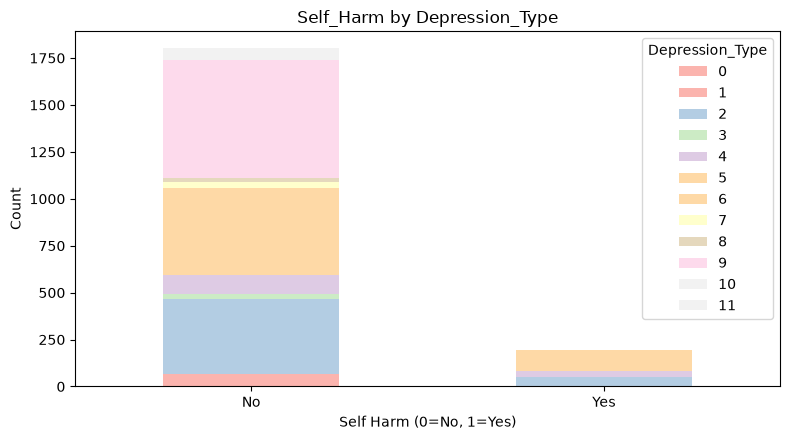

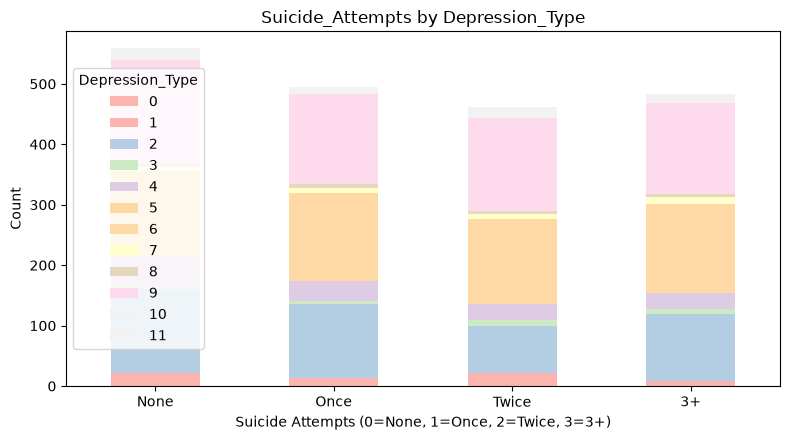

In [6]:
# Stacked bar charts for categorical variables with clearer encoding labels
for col in categorical_cols:
    ct = pd.crosstab(df[col], df[target])
    ax = ct.plot(kind="bar", stacked=True, figsize=(8, 4.5), colormap="Pastel1")
    ax.set_title(f"{col} by {target}")
    ax.set_xlabel(get_axis_label(col, "xlabel"))
    ax.set_ylabel("Count")
    relabel_axis_ticks(ax, col, axis="x")
    plt.tight_layout()
    plt.show()

## 5. Numerical variable analysis

In [7]:
numerical_focus= ['Age', 'Low_Energy', 'Sleep_Hours', 'SocialMedia_Hours','Your overeating level', 'Low_SelfEsteem', 'Nervous_Level', 'Depression_Score']

summary_tables = {}
for col in numerical_focus:
    summary = df.groupby(target)[col].agg(["mean", "median", "std"]).round(3)
    summary_tables[col] = summary
    print("\n", "="*80)
    print(f"Summary for {col}")
    print(summary)



Summary for Age
                   mean  median    std
Depression_Type                       
0                23.125    25.0  8.590
1                25.303    25.0  7.064
2                23.820    25.0  8.193
3                24.194    25.0  7.314
4                24.313    25.0  7.863
5                24.365    25.0  7.899
6                24.378    25.0  7.474
7                24.531    25.0  7.444
8                25.000    25.0  8.660
9                24.482    25.0  7.889
10               21.724    25.0  8.689
11               25.588    25.0  8.596

Summary for Low_Energy
                  mean  median    std
Depression_Type                      
0                1.000     1.0  0.000
1                1.000     1.0  0.000
2                0.824     1.0  0.381
3                1.000     1.0  0.000
4                1.000     1.0  0.000
5                0.617     1.0  0.487
6                0.606     0.0  0.743
7                0.000     0.0  0.000
8                0.000     0.0  0

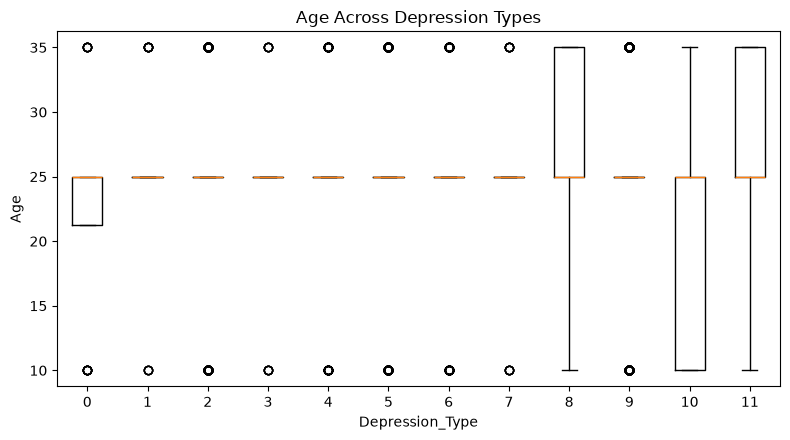

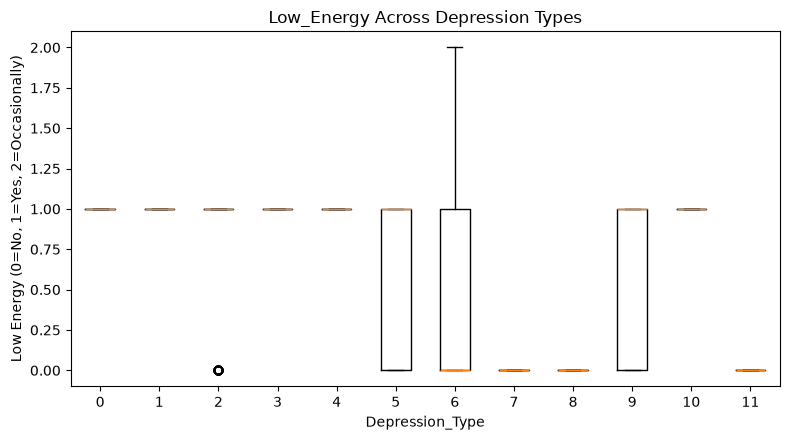

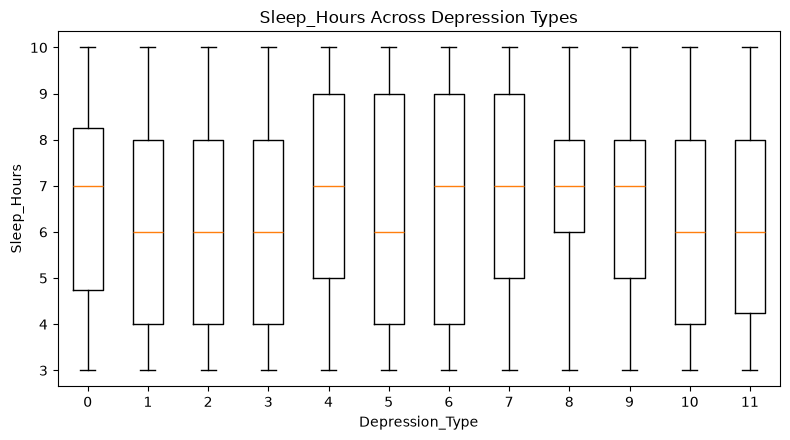

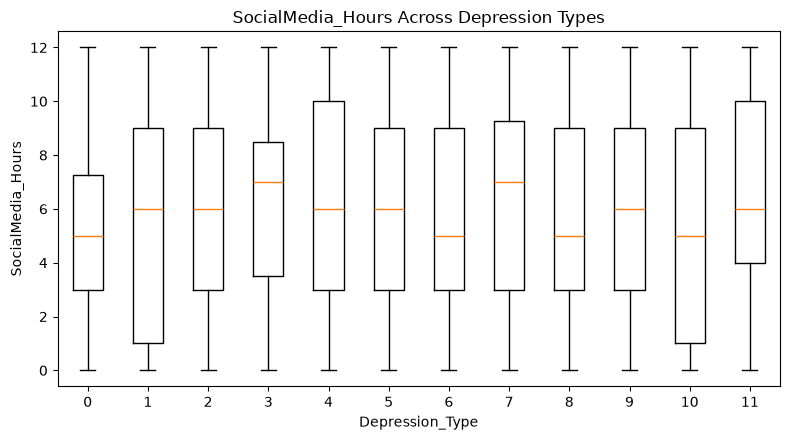

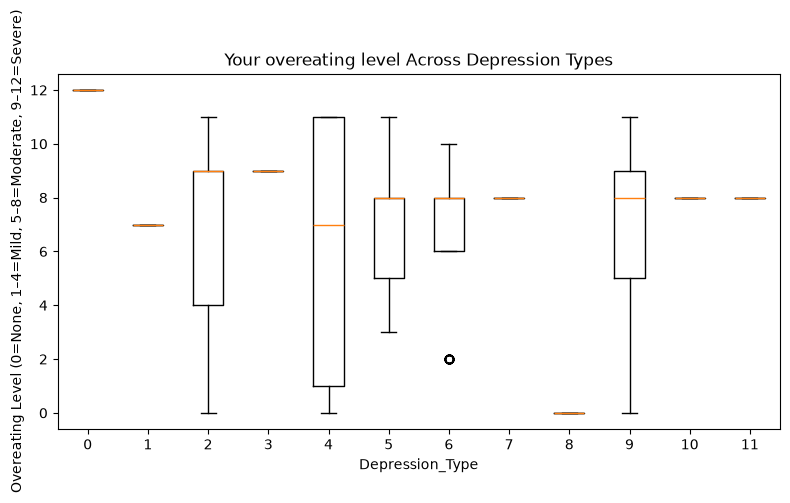

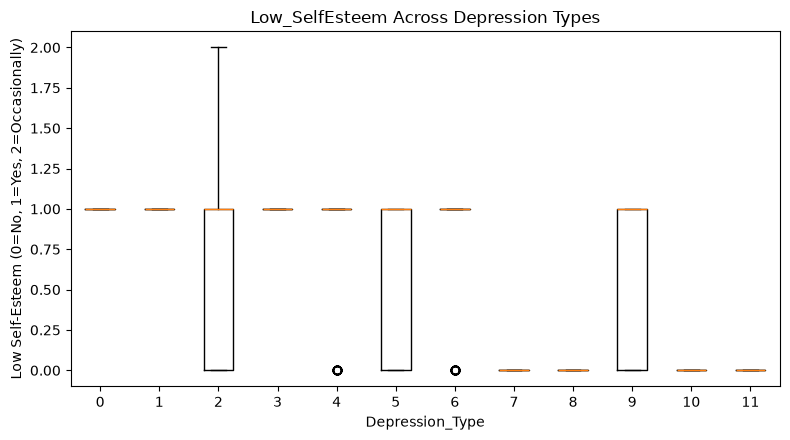

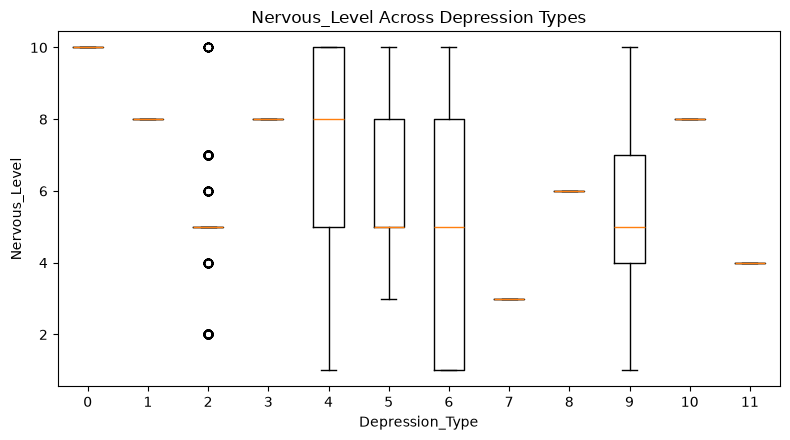

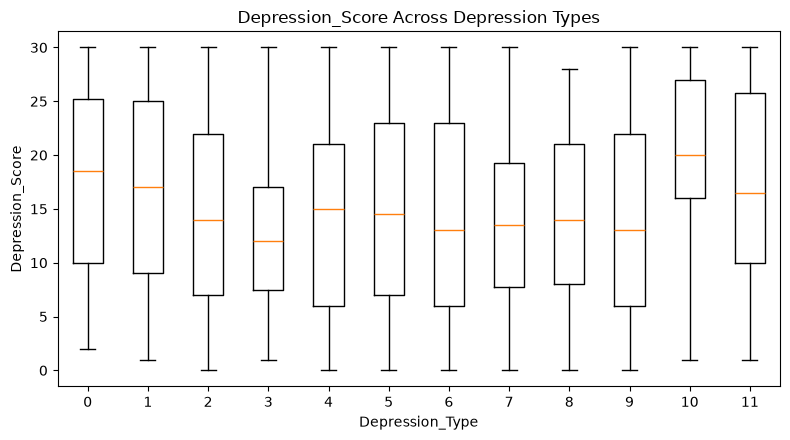

In [8]:
for col in numerical_focus:
    ordered_classes = sorted(df[target].unique())
    data = [df.loc[df[target] == c, col].values for c in ordered_classes]

    plt.figure(figsize=(8, 4.5))
    plt.boxplot(data, tick_labels=[str(c) for c in ordered_classes])
    plt.title(f"{col} Across Depression Types")
    plt.xlabel(target)
    plt.ylabel(get_axis_label(col, "ylabel"))
    plt.tight_layout()
    plt.show()

## 6. Train-test split and model comparison

In [9]:
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)


Training shape: (1598, 20)
Test shape: (400, 20)


In [10]:
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000))
])

lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred)
    ],
    "Macro F1": [
        f1_score(y_test, lr_pred, average="macro"),
        f1_score(y_test, nb_pred, average="macro")
    ]
}).round(4)

results


,Model,Accuracy,Macro F1
0,Logistic Regression,0.7175,0.8659
1,Naive Bayes,0.5325,0.7563


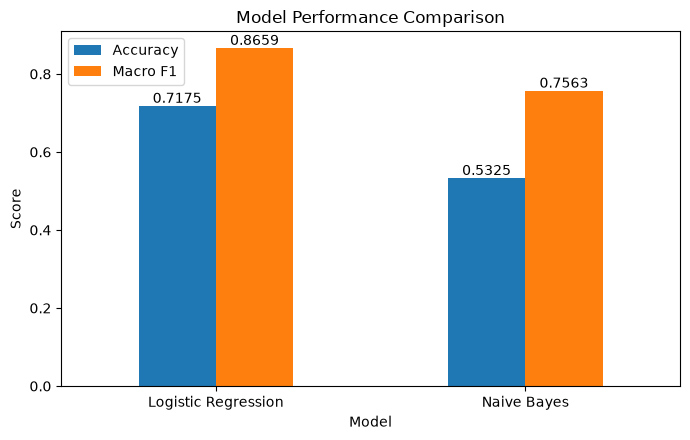

In [11]:
ax = results.set_index('Model').plot.bar(rot=0,figsize=(7,4.5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
for bc in ax.containers:
  ax.bar_label(bc)
plt.tight_layout()
plt.show()

## 7. Detailed evaluation

In [12]:
print("Logistic Regression classification report")
print(classification_report(y_test, lr_pred, zero_division=0))

print("\nNaive Bayes classification report")
print(classification_report(y_test, nb_pred, zero_division=0))


Logistic Regression classification report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       0.88      1.00      0.93         7
           2       0.63      0.64      0.64        90
           3       1.00      1.00      1.00         6
           4       0.66      0.88      0.75        26
           5       0.63      0.42      0.50        77
           6       0.86      0.77      0.81        39
           7       1.00      1.00      1.00         6
           8       1.00      1.00      1.00         4
           9       0.71      0.81      0.76       126
          10       1.00      1.00      1.00         6
          11       1.00      1.00      1.00         7

    accuracy                           0.72       400
   macro avg       0.86      0.88      0.87       400
weighted avg       0.71      0.72      0.71       400


Naive Bayes classification report
              precision    recall  f1-score   support

 

## 8. Logistic Regression feature signals

In [13]:
coef_matrix = lr_model.named_steps["model"].coef_
feature_importance = pd.Series(
    np.mean(np.abs(coef_matrix), axis=0),
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)


SocialMedia_WhileEating     1.540118
Low_SelfEsteem              1.138025
Search_Depression_Online    1.131883
Symptoms                    1.017513
Education_Level             0.966997
Nervous_Level               0.966372
Your overeating level       0.927644
How many times you eat      0.917560
Self_Harm                   0.900431
Low_Energy                  0.847324
dtype: float64

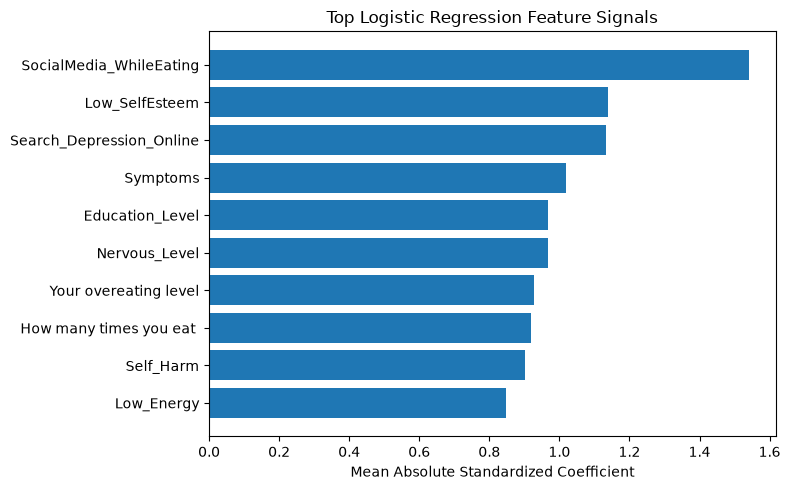

In [14]:
top_features = feature_importance.head(10).sort_values()

plt.figure(figsize=(8, 5))
plt.barh(range(len(top_features)), top_features.values)
plt.yticks(range(len(top_features)), top_features.index)
plt.xlabel("Mean Absolute Standardized Coefficient")
plt.title("Top Logistic Regression Feature Signals")
plt.tight_layout()
plt.show()


## 9. Confusion matrix for Logistic Regression

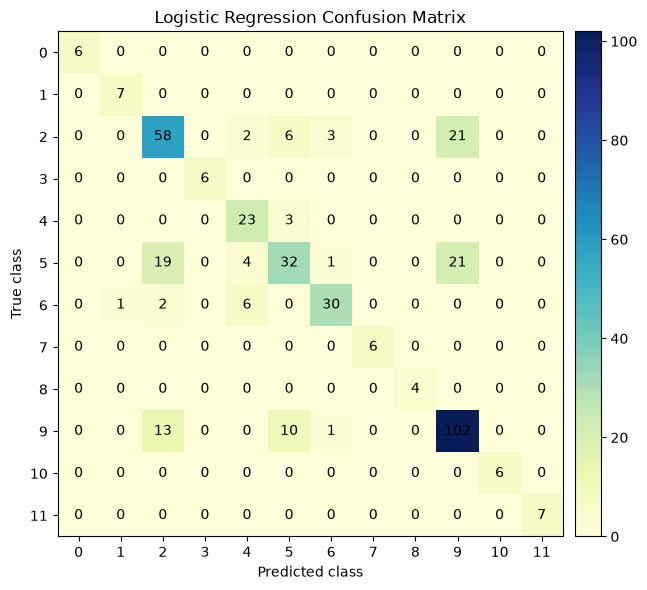

In [15]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

ordered_classes = sorted(y_test.unique())
cm = confusion_matrix(y_test, lr_pred, labels=ordered_classes)

plt.figure(figsize=(7, 6))
im = plt.imshow(cm, cmap='YlGnBu')

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("True class")

plt.xticks(range(len(ordered_classes)), [str(c) for c in ordered_classes])
plt.yticks(range(len(ordered_classes)), [str(c) for c in ordered_classes])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center",
                 color="black")

plt.colorbar(im, fraction=0.04, pad=0.02)
plt.tight_layout()
plt.show()

## 10. Key interpretation

- the target classes are imbalanced, so Macro F1-score is essential
- several categorical variables show strong class association
- **Low_Energy** behaves like a stronger signal than more contextual variables such as sleep
- Logistic Regression outperforms Gaussian Naive Bayes because the predictors are not independent
- the confusion matrix shows that the task is meaningful but still difficult because some classes overlap
